# 03 — Exploratory Data Analysis (EDA)
**NST DVA Capstone 2 | B_G6_DIGITOMICS**

**Sector:** EdTech / Digital Behaviour Analytics  
**Dataset:** Student Digital Behaviour Data  
**Notebook Purpose:** Explore data distributions, identify trends, and analyze outliers in the cleaned student digital behavior dataset.

---
## Pipeline Steps:
1. Load cleaned data
2. Univariate Analysis (Distributions & Counts)
3. Bivariate Analysis (Trends & Relationships)
4. Outlier Detection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded for EDA.")

Libraries loaded for EDA.


In [2]:
# Load the cleaned dataset
PROCESSED_PATH = '../data/processed/student_digital_behaviour_cleaned.csv'
df = pd.read_csv(PROCESSED_PATH)

print(f"Data Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Data Loaded: 500,000 rows × 58 columns


,student_id,country,development_level,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,...,late_night_usage_encoded,cyberbullying_exposure_flag,adult_content_exposure_flag,brain_rot_level_encoded,productive_digital_ratio,sleep_risk_flag,high_stress_flag,total_screen_hours,mental_health_composite,academic_risk_category
0,1,Qatar,Developing,16.30,54.93,27.19,21,Male,Rural,High,...,1.0,0,0,1.0,0.2164,0,0,11.523,2.9547,Low Risk
1,2,Usa,Developed,8.75,94.39,85.34,25,Male,Urban,Middle,...,2.0,0,1,1.0,0.0682,1,1,13.758,7.9912,Low Risk
2,3,Mexico,Developing,23.64,47.24,73.55,18,Female,Urban,Low,...,1.0,0,0,1.0,0.1789,0,0,7.354,1.8835,Low Risk
3,4,Canada,Developed,14.51,90.50,188.19,25,Male,Urban,Middle,...,0.0,0,1,1.0,0.3802,0,0,10.926,3.6574,Low Risk
4,5,Sri Lanka,Underdeveloped,62.28,36.84,11.02,15,Other,Rural,Middle,...,1.0,0,0,1.0,0.1963,1,0,13.773,5.4276,Low Risk


## 1. Univariate Analysis
Examining the distributions of our key numerical metrics: Productivity, Digital Addiction, and Wellbeing.

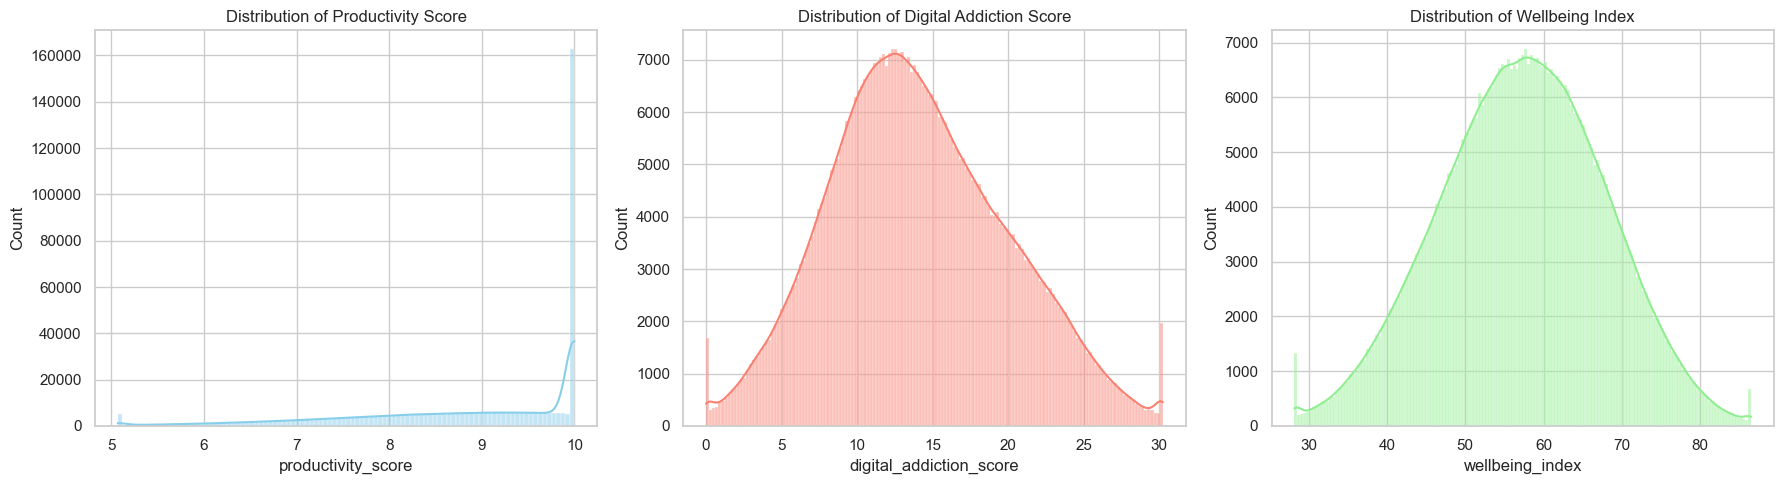

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['productivity_score'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Productivity Score')

sns.histplot(df['digital_addiction_score'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Digital Addiction Score')

sns.histplot(df['wellbeing_index'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Wellbeing Index')

plt.tight_layout()
plt.show()

Observations:
- The distributions give us a sense of central tendency.
- We can observe if digital addiction is skewed and how normal the wellbeing index is distributed.

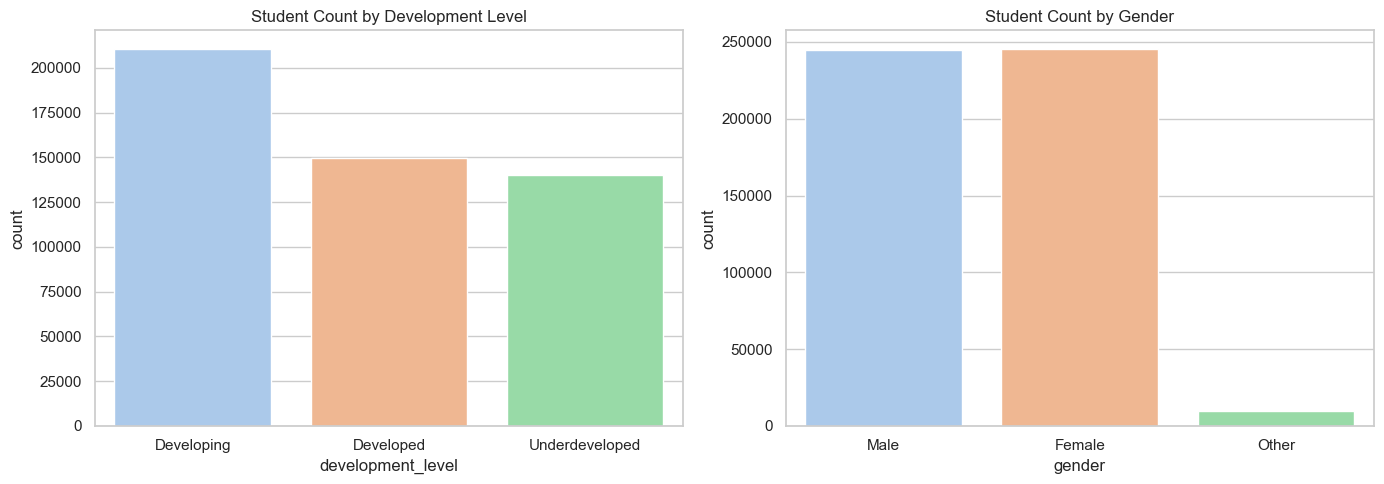

In [4]:
# Categorical distributions: Development Level and Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='development_level', ax=axes[0], palette='pastel')
axes[0].set_title('Student Count by Development Level')

sns.countplot(data=df, x='gender', ax=axes[1], palette='pastel')
axes[1].set_title('Student Count by Gender')

plt.tight_layout()
plt.show()

## 2. Bivariate Analysis & Trends
How does social media usage impact productivity and sleep?

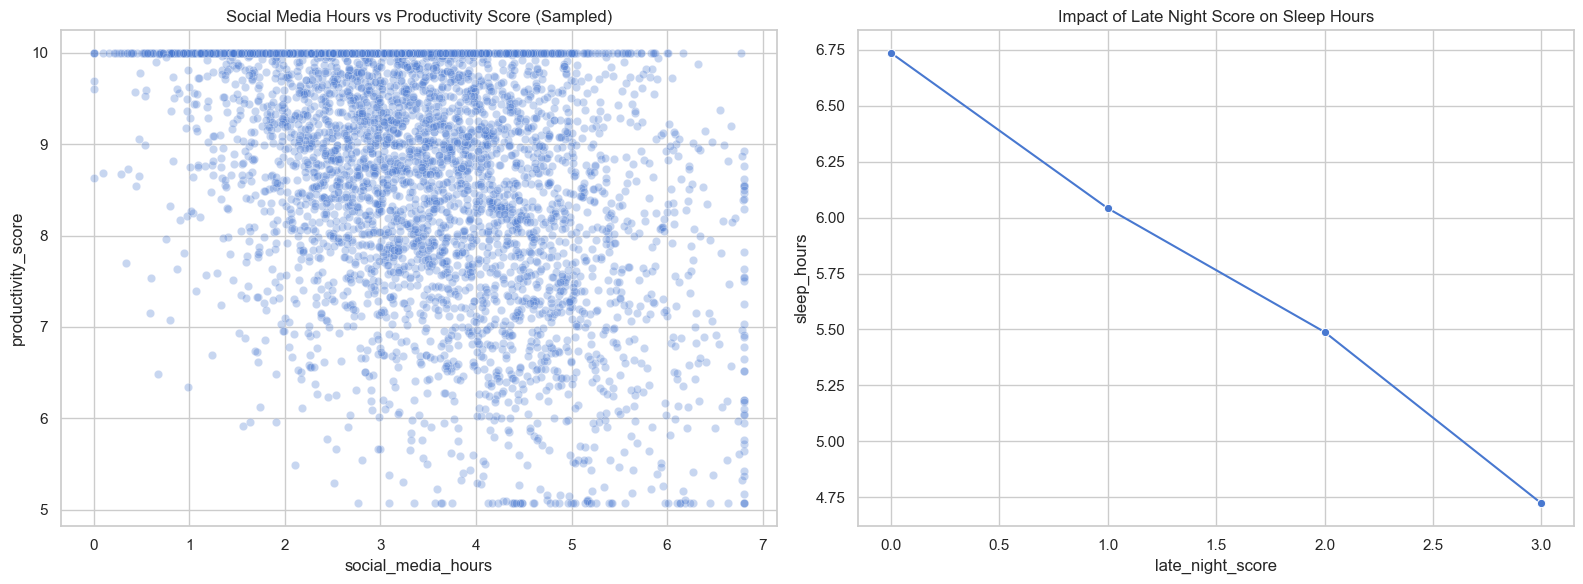

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df.sample(min(5000, len(df))), x='social_media_hours', y='productivity_score', alpha=0.3, ax=axes[0])
axes[0].set_title('Social Media Hours vs Productivity Score (Sampled)')

sns.lineplot(data=df, x='late_night_score', y='sleep_hours', marker='o', ax=axes[1], errorbar=None)
axes[1].set_title('Impact of Late Night Score on Sleep Hours')

plt.tight_layout()
plt.show()

## 3. Outlier Detection
Checking for outliers in academic risk and screen time using boxplots.

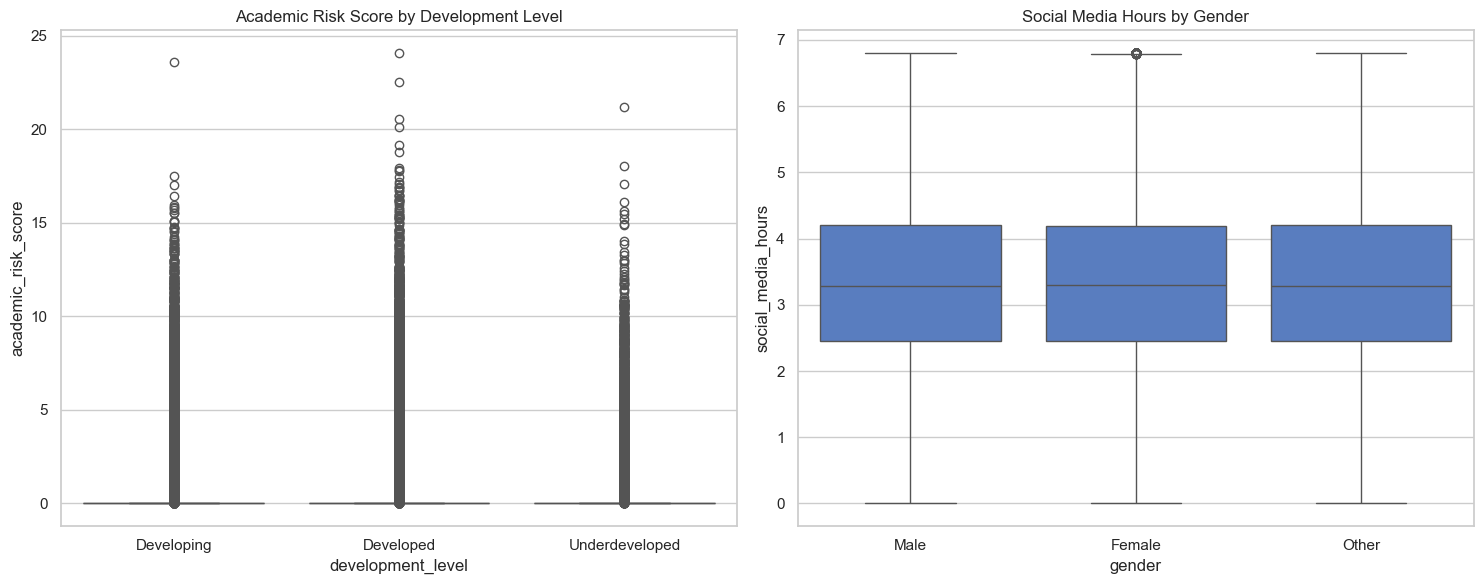

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='development_level', y='academic_risk_score', ax=axes[0])
axes[0].set_title('Academic Risk Score by Development Level')

sns.boxplot(data=df, x='gender', y='social_media_hours', ax=axes[1])
axes[1].set_title('Social Media Hours by Gender')

plt.tight_layout()
plt.show()

**Conclusion of EDA:**
- Strong initial visual indications that high digital usage correlates with specific academic risks.
- Distributions mapped successfully for downstream modeling.
